# Social Data Analysis: Communities and Link Prediction



## First, let's install the potentially missing libraries 
(not necessary if you are certain these libs are installed on your system)

In [1]:
%pip install -q pandas
%pip install -q networkx
%pip install -q seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Second, let's import the useful packages
You can avoid the first line if you are not using a Jupyter notebook. This line enables the visualization to be displayed in the notebook.

In [1]:
%matplotlib inline

import networkx as nx
from networkx.algorithms import community 
from networkx.algorithms.community import * 
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import random

## Good, if you have not encounter any problems, we can start working now!

### First download the dataset (either visit my [professional web page](www.irit.fr/~Yoann.Pitarch) or the Moodle space of this course)

In [5]:
pathData = "TP2/data/lesmis.gml"
GD = nx.DiGraph(nx.read_gml(pathData))

### Then, navigate through the documentation of the networkx package and find how to load networks in the GML format

You can have a look to this file by openning it with a basic text editor. Note that the graph is __undirected__.


The graph is weakly connected.
Number of weakly connected components: 1
Weakly connected components: [{'Child1', 'OldMan', 'Zephine', 'Perpetue', 'CountessDeLo', 'Javert', 'Bamatabois', 'Brevet', 'Woman2', 'Anzelma', 'Labarre', 'Enjolras', 'Blacheville', 'Gavroche', 'MlleBaptistine', 'Courfeyrac', 'Marius', 'Listolier', 'Brujon', 'Pontmercy', 'Cosette', 'MmeThenardier', 'Mabeuf', 'Gueulemer', 'Champtercier', 'Fauchelevent', 'MotherPlutarch', 'Tholomyes', 'Toussaint', 'MmePontmercy', 'Thenardier', 'MlleVaubois', 'Bossuet', 'Eponine', 'Babet', 'Favourite', 'Napoleon', 'Scaufflaire', 'Magnon', 'Joly', 'Gribier', 'MmeHucheloup', 'Boulatruelle', 'Marguerite', 'Montparnasse', 'Chenildieu', 'MmeBurgon', 'Isabeau', 'Bahorel', 'Fantine', 'Cochepaille', 'Child2', 'MlleGillenormand', 'MmeMagloire', 'Grantaire', 'MmeDeR', 'Jondrette', 'Gillenormand', 'Woman1', 'Myriel', 'Judge', 'Claquesous', 'Feuilly', 'BaronessT', 'Geborand', 'Combeferre', 'Champmathieu', 'Valjean', 'MotherInnocent', 'Gervais', 

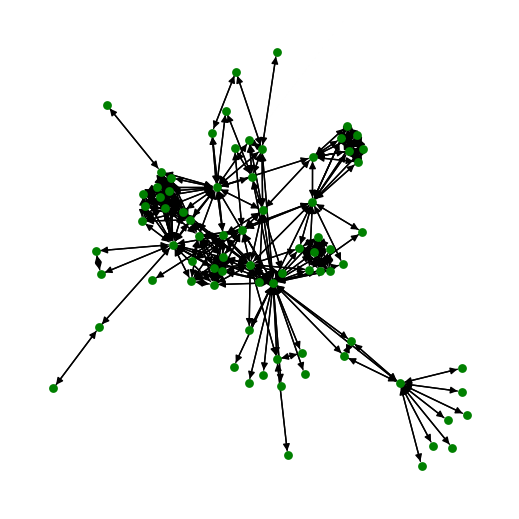

In [6]:
def get_GraphFile_information(GD,node_size=40):
    # Check weak connectivity
    if nx.is_weakly_connected(GD):
        print("The graph is weakly connected.")
    else:
        print("The graph is not weakly connected.")
    # Number of weakly connected components
    num_wcc = nx.number_weakly_connected_components(GD)
    print(f"Number of weakly connected components: {num_wcc}")
    # Generate weakly connected components
    wcc = list(nx.weakly_connected_components(GD))
    print("Weakly connected components:", wcc)

    print("Ordre : ", nx.number_of_nodes(GD), "sommets")
    print("Taille : ", nx.number_of_edges(GD), "liens")
    print("Réseau orienté ?", nx.is_directed(GD))
    print("attribut des liens : ", list(list(GD.edges(data=True))[0][-1].keys()))
    print("attribut des sommets : ", list(list(GD.nodes(data=True))[0][-1].keys()))

    fig = plt.figure(figsize = (5, 5))
    nx.draw(GD,node_size=node_size, node_color='green', linewidths=0.01)
    plt.show()
    return GD

# Read the GML file
get_GraphFile_information(GD)

In [7]:
print(nx.__version__)

3.4.2


# Community detection 

In this section, we will focus on community detection algorithm. 
- __Identify linked, cohesive clusters of nodes (eg., identify cinephils in social networks)__

For this, have a look to the networkx package documentation and apply the following community detection algorithms:
 
1. Kernighan–Lin bipartition algorithm
2. Percolation method
3. Fluid communities algorithm
4. Girvan-Newman method
 
- When the number of communities to detect has to be specified as a parameter, 
- you will use the coverage metric to select the appropriate number (ranging from 2 to 5).
- Finally, for each community algorithm, you will add an attribute to each node of the graph. 
- The value of the attribute will be the identifier of the community the node belongs to (ranging from 0 to nbCommunity -1).

## Community visualization

 - We will now visualize the result of the communication detection algorithm. 
 - For this, we start by filtering out some nodes from the visualisation.
 -  Particularly, we would like to filter out nodes that do not belong to any communities according to the percolation method. 
 - To do so, you need to create a list that contains the label of nodes belonging to a community according to the percolation method.    
 - You can use the following dictionnary to set the visualisation options.

/Users/asriel/miniconda3/envs/311_env/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


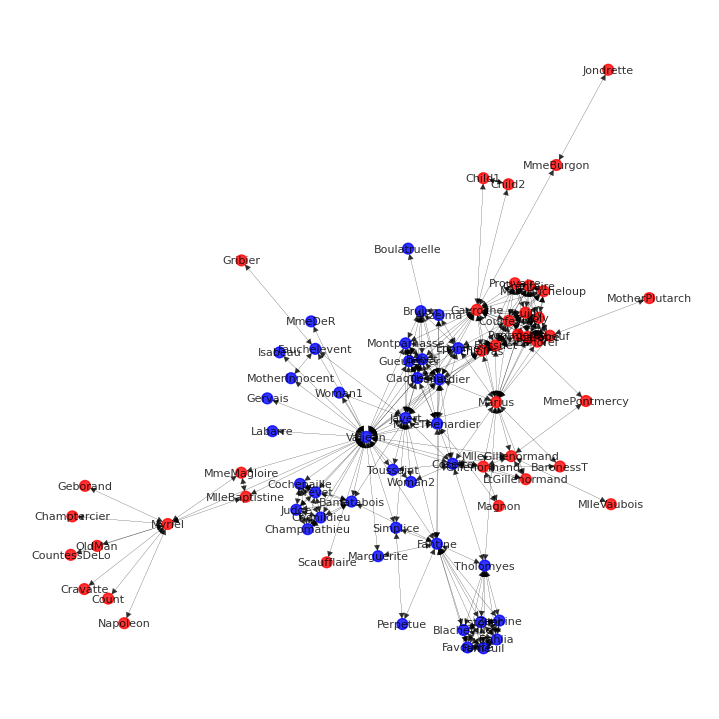

In [8]:

def dawing_graph(GD,color_map):
    options = {
        'node_color' : color_map, # a list that contains the community id for the nodes we want to plot
        'node_size' : 60, 
        'cmap' : plt.get_cmap("turbo"),
        'node_shape' : 'o',
        'with_labels' : True, 
        "width" : 0.1, 
        "font_size" : 8,
        "nodelist" : GD.nodes(), # A list that contains the labels of the nodes we want to plot
        "alpha" : 0.8  }

    plt.figure(figsize=(7,7))
    nx.draw(GD,**options)

GU = nx.read_gml(pathData)

# Extract the two sets of nodes
community_1, community_2 =  kernighan_lin_bisection(GU)
# Create a color map for visualization
color_map = []
for node in GU:
    if node in community_1:
        color_map.append('red')
    elif node in community_2:
        color_map.append('blue')
    else:    
        color_map.append('green')

GU = GD.to_undirected()
dawing_graph(GD,color_map)

#### **Kernighan–Lin Algorithm**   

 **Key Features of the & Objective**:    
 The primary goal is to divide the graph into two sets such that the number of edges between the sets (or their total weight if weighted) is minimized.
 - **Input**:    
    - An undirected graph $G=(V,E)$ with vertices $V$ and edges $E$. 
    - The edges may have weights, which are used to calculate the cost of partitioning.
 - **Process**:   
    - Initially, the graph is split into two equal (or nearly equal) parts.   
    - The algorithm iteratively improves this partition by swapping pairs of nodes between the two sets to reduce the edge cut.   
    - In each iteration, it calculates a gain function based on the difference in external and internal edge costs for each node.   
    - Nodes are selected for swapping if they maximize the reduction in edge cut.   
 - **Complexity**: 
    -   Each pass of the algorithm runs in $O(n^2 log(n))$, where n is the number of vertices in the graph   

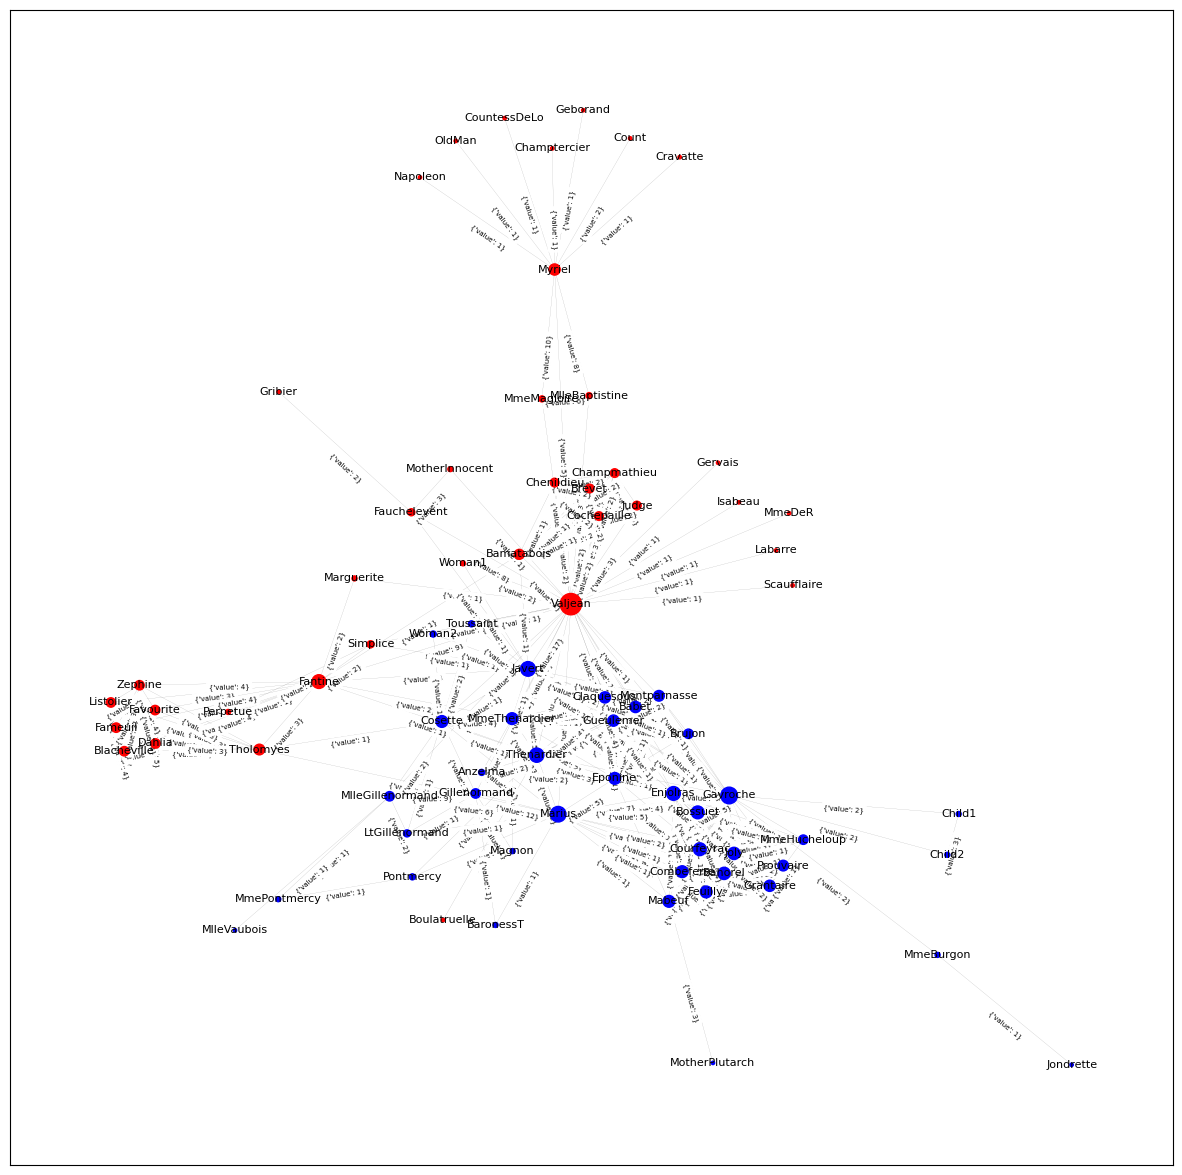

In [9]:
import networkx as nx
from networkx.algorithms.community import kernighan_lin_bisection, kernighan_lin 

def Drawing_graph(GD, color_map, hsize=15, vsize=15):
    degree_centrality = nx.degree_centrality(GD)
    # Get the minimum and maximum degree centrality values
    min_degree = min(degree_centrality.values())
    max_degree = max(degree_centrality.values())# Create a colormap
    cmap = mpl.colormaps['turbo']
    # Normalize the degree centrality values
    norm = mpl.colors.Normalize(vmin=min_degree, vmax=max_degree)
    # Map degree centrality to colors
    node_colors = [cmap(norm(degree)) for degree in degree_centrality.values()]
    # Plot the graph
    pos = nx.spring_layout(GD)
    # Calculate node sizes based on degree centrality
    node_sizes = [int(degree * 500) for degree in degree_centrality.values()]

    fig = plt.figure(figsize = (vsize, hsize))  
    nx.draw_networkx_nodes(GD, pos, node_color=color_map, node_size=node_sizes)
    nx.draw_networkx_edges(GD, pos, width=0.1, edge_color='gray')
    nx.draw_networkx_labels(GD, pos, font_size=8)
    nx.draw_networkx_edge_labels(GD, pos,verticalalignment='top', font_size=5)


community_1, community_2 =  kernighan_lin_bisection(GU)
# Create a color map for visualization
color_map = []
for node in GU:
    if node in community_1:
        color_map.append('red')
    else:
        color_map.append('blue')

Drawing_graph(GU, color_map, hsize=15, vsize=15)

:::

#### **Percolation theory** : 
 - Percolation is based on a mathematical framework used to describe the behavior of connected clusters in a random graph.
 - It is particularly useful in understanding phase transitions and the formation of large connected components in networks. 
 - Here are some key concepts and formulas associated with percolation theory:

**Key Concepts**
 - Percolation Threshold 
 - Bond Percolation 
 - Site Percolation 
 - Directed Percolation


**Clique Percolation Method (CPM)**: 
 - k-clique community is the set of nodes belonging to a maximal set of k-cliques that can be reached from each other through a series of adjacent k-cliques.

::: 

:::

#### **K-cliques method** : 

This method formalizes the notion of community as a maximal union of k-cliques that can be reached from each other through a series of adjacent k-cliques, where two cliques are adjacent if and only if they overlap on k − 1 nodes.

 - Finding cliques and maximum cliques (using a brut-force algorithm)
 - are NP-hard problems, costly in terms of time complexity.
 - Impractical for large networks

:::

:::

**In summary, while both k-clique and percolation theory deal with connectivity, k-clique focuses on complete subgraphs within deterministic networks, often used for analyzing social or biological networks.** 

**In contrast, percolation theory deals with stochastic processes and phase transitions in random graphs, with applications spanning physics, ecology, and beyond.**

:::


:::

L'une des limites parmi les algorithmes de détection communautaire les plus utilisés est qu'ils ne peuvent qu'attribuer chaque noeud (symptôme) à une communauté unique, il ne sont pas en mesure d'identifier les noeuds symptômes qui se chevauchent. 

:::

:::

La percolation de clique (CP) est un algorithme qui identifie les symptômes qui se chevauchent, mais sa performance n'a pas été évaluée dans les réseaux psychologiques.

:::

:::

Dans les réseaux psychologiques, l'interprétation spécifique d'une communauté de réseau est qu'elle indique des comportements, des cognitions et des émotions qui établissent de forts effets causaux mutuellement renforcés par rapport à d'autres comportements, cognitions et émotions dans le réseau psychologique.

:::





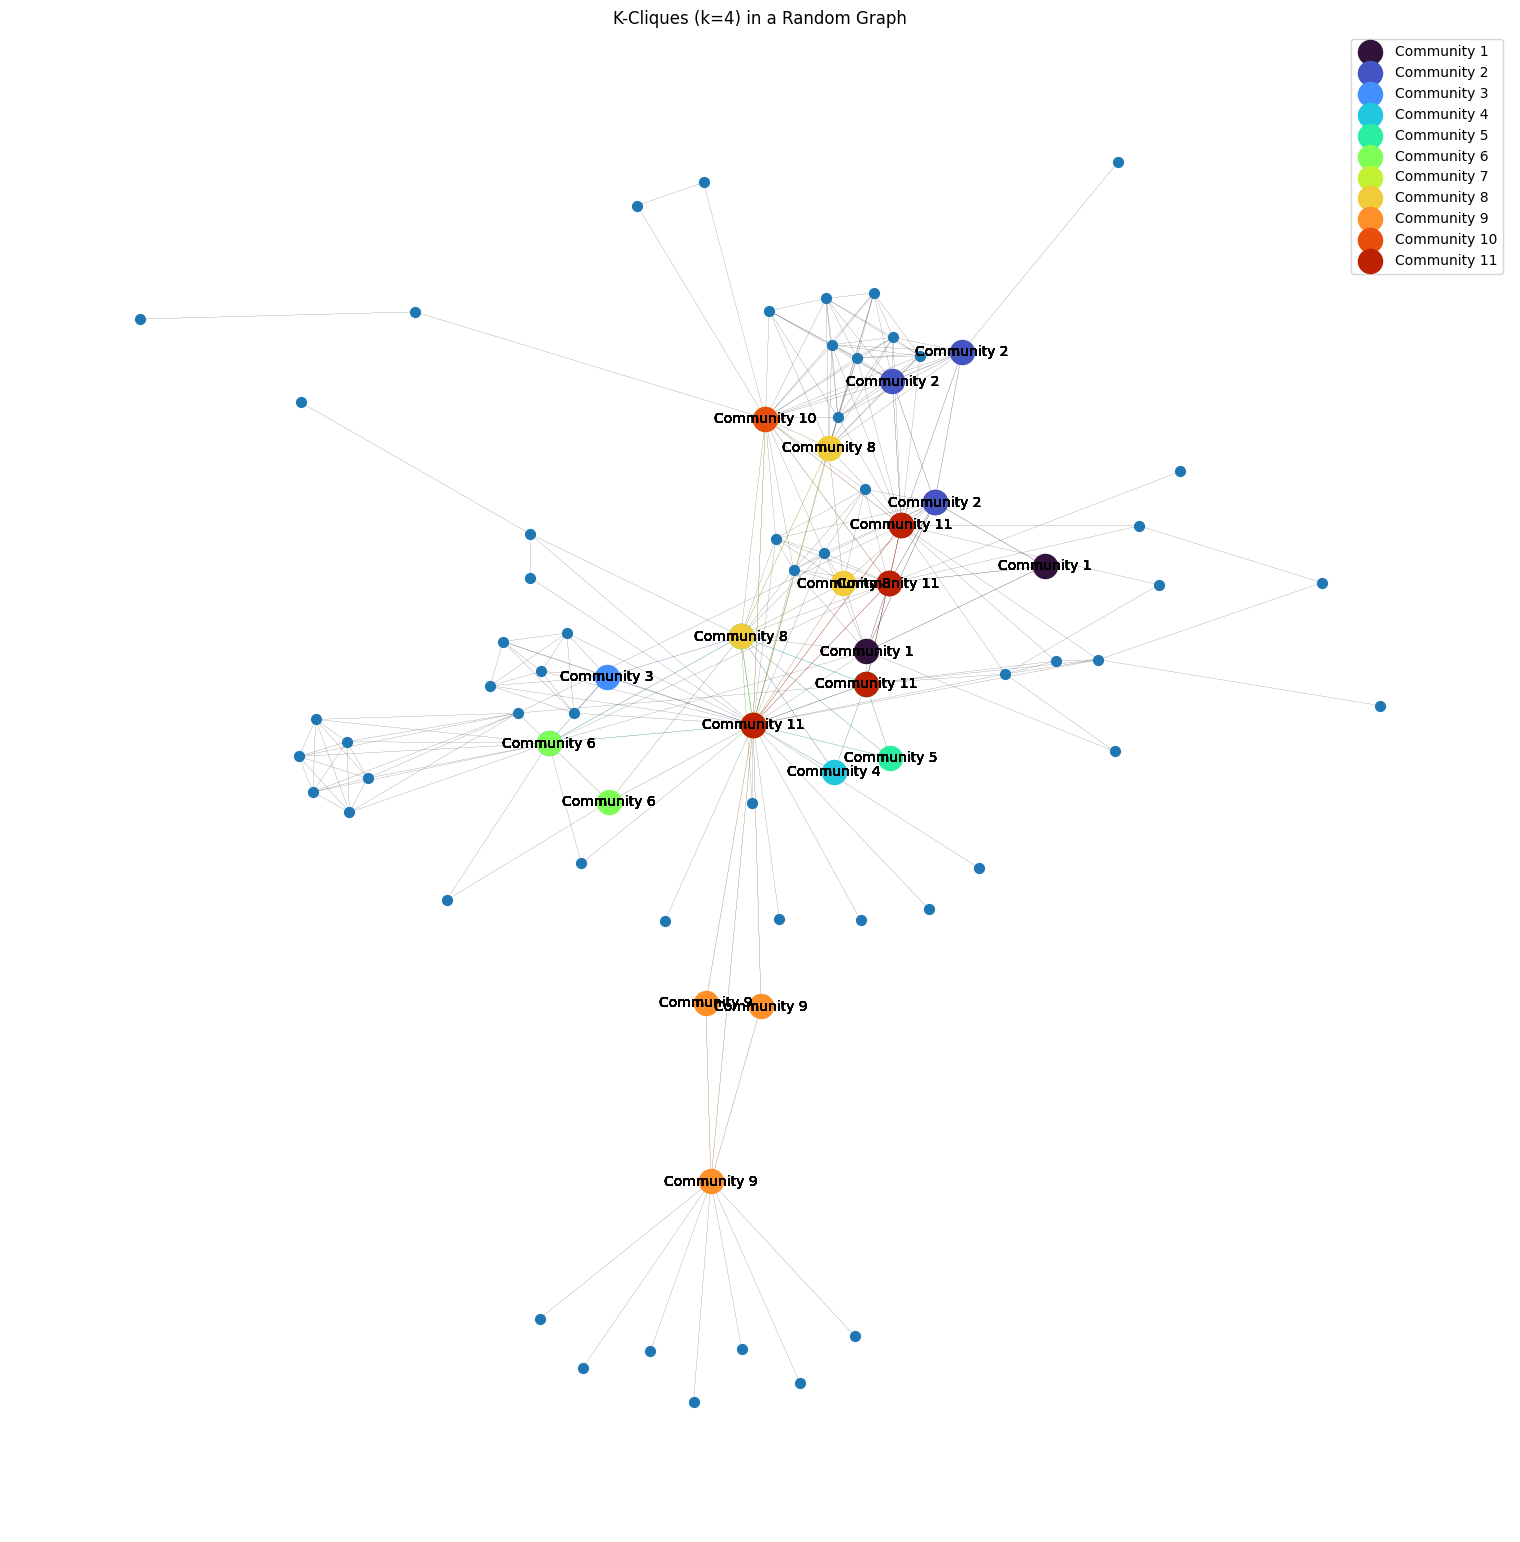

In [10]:
import random

def display_k_cliques_graph(G, k):
    # Find all cliques in the graph
    cliques = list(nx.find_cliques(G))    
    # Filter cliques for size k
    k_cliques = [clique for clique in cliques if len(clique) == k]
    group_names = [f'Community {i+1}' for i in range(len(k_cliques))]

    # Add the name attribute to each node in the communities
    for community, name in zip(k_cliques, group_names):
        for node in community:
            G.nodes[node]['name'] = name

    fig = plt.figure(figsize = (15, 15))  
    # Draw the graph with light gray nodes by default
    pos = nx.spring_layout(G)
    # Draw each k-clique with a unique color and thicker edges
    nx.draw(G, pos, width=0.1, with_labels=False, node_size=50)    
    # Use the 'turbo' colormap
    cmap = plt.colormaps['turbo']

    # Draw each k-clique with a unique color from the colormap
    for i, clique in enumerate(k_cliques):
        color = cmap(i / len(k_cliques))  # Get a color from the colormap
        nx.draw_networkx_nodes(G, pos, nodelist=clique, node_color=[color], node_size=300,  label=f'Community {i+1}')
        edges_in_clique = [(clique[i], clique[j]) for i in range(len(clique)) for j in range(i + 1, len(clique))]
        nx.draw_networkx_edges(G, pos, edgelist=edges_in_clique, width=0.1, edge_color=[color]) 
        labels = nx.get_node_attributes(G, 'name')
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)
        #nx.draw_networkx_edge_labels(G, pos,verticalalignment='top', font_size=5)

    plt.title(f'K-Cliques (k={k}) in a Random Graph')
    plt.legend(loc='best')
    plt.show()

GD = nx.DiGraph(nx.read_gml(pathData))
GU = GD.to_undirected()
G = GU.copy()
display_k_cliques_graph(G, 4)

### **Fluid Communities**

**Asynchronous Fluid Communities algorithm for community detection.** 

- The Fluid Communities algorithm is a community detection method that draws inspiration from the behavior of fluids interacting within an environment.   
- Here are the key concepts associated with this algorithm : 

**Concept**: 
- Based on the idea of multiple fluids (representing communities) interacting within a non-homogeneous environment, which in this context is a graph.    
- These fluids expand and contract based on their interactions and densities, influenced by the graph's topology.

**Mechanism**:
- The algorithm initializes a number of fluid communities, each starting from a random vertex in the graph.
- Each community has an associated density, which inversely relates to the number of vertices it contains.
- As these fluid communities expand and push against each other, they eventually reach a stable state where the communities are well-defined.  

**Features:**
    
- **Scalability**: Fluid Communities is designed to be computationally efficient and scalable, making it suitable for large networks.
- **Flexibility**: It allows specifying the number of communities to be detected by initializing different numbers of fluids. This feature provides flexibility in analyzing networks at various levels of granularity.
- **Propagation Methodology**: It employs a propagation-based approach, similar to other algorithms like Label Propagation, but with unique characteristics that allow for variable community detection.
- **Applications**: This algorithm can be used in various fields such as social network analysis, biological networks, and any domain where understanding the structure of interconnected components is crucial.

**In summary, the Fluid Communities algorithm is a novel approach to community detection that leverages the metaphor of fluid dynamics to identify clusters within graphs. It is particularly noted for its scalability and ability to detect a variable number of communities efficiently.**



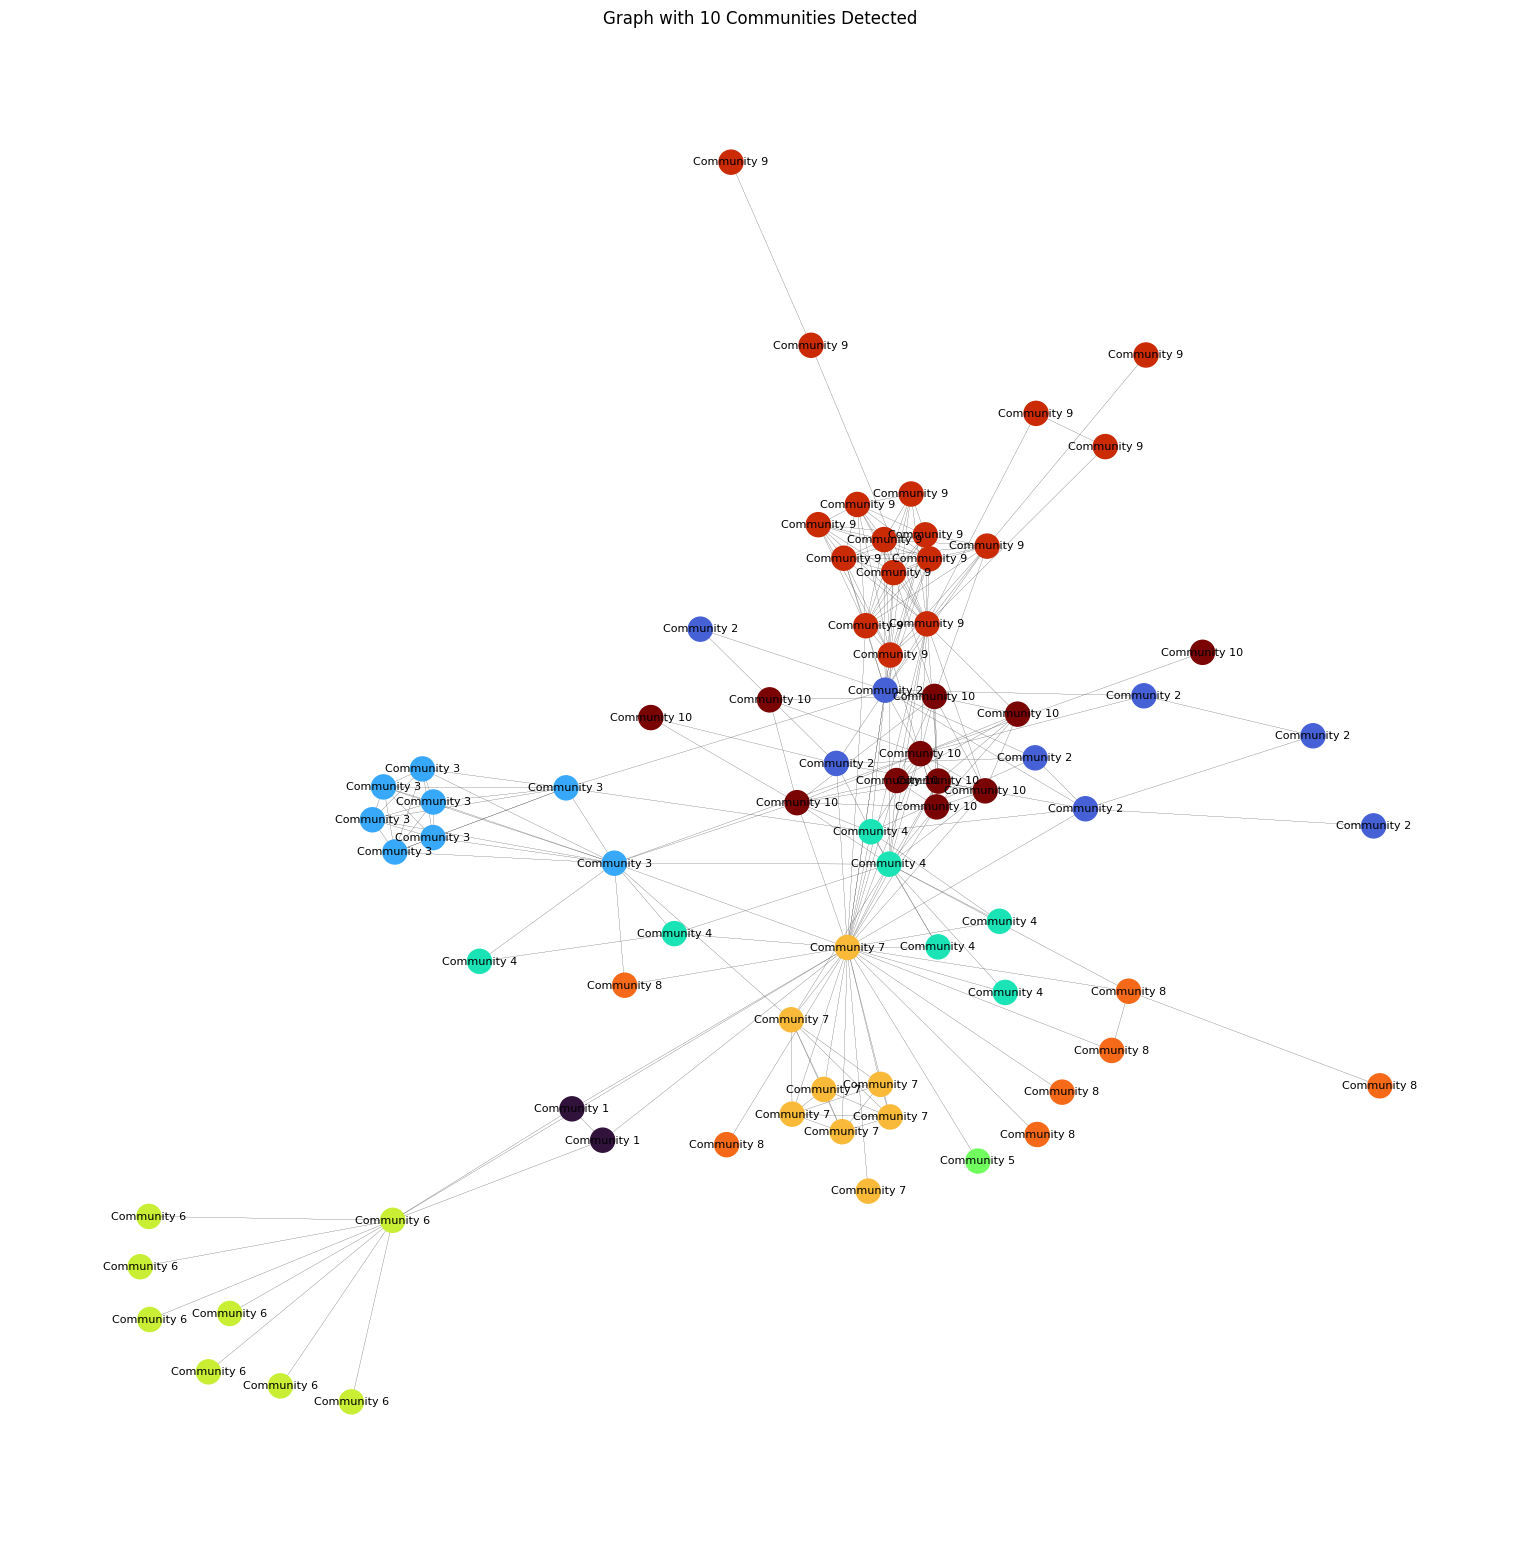

In [11]:
from networkx.algorithms.community import kernighan_lin_bisection, asyn_fluidc
import numpy as np

def display_communities_with_colors(G, k): 
    # Detect communities using the Fluid Communities algorithm
    communities = list(asyn_fluidc(G, k))
    # Create a list of colors for each community
    group_names = [f'Community {i+1}' for i in range(len(communities))]

    # Add the name attribute to each node in the communities
    for community, name in zip(communities, group_names):
        for node in community:
            G.nodes[node]['name'] = name

    # Use the 'turbo' colormap 
    colors = plt.cm.turbo(np.linspace(0, 1, len(communities))) 
    # Assign a color to each node based on its community
    node_colors = []
    for node in G:
        for i, community in enumerate(communities):
            if node in community:
                node_colors.append(colors[i])
                break

    # Draw the graph with nodes colored by their community
    plt.figure(figsize = (15, 15)) 
    pos = nx.spring_layout(G)
    nx.draw(G, pos, node_color=node_colors, width=0.1, with_labels=False, node_size=200)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300,  label=f'Community {i+1}')
    nx.draw_networkx_edges(G, pos, width=0.1, edge_color='gray')
    labels = nx.get_node_attributes(G, 'name')
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    plt.title(f'Graph with {k} Communities Detected')
    plt.axis('off')
    #plt.legend()
    plt.show()

GD = nx.DiGraph(nx.read_gml(pathData))
GU = GD.to_undirected()
G = GU.copy()
display_communities_with_colors(G,10)

### **Girvan-Newman method**

The Girvan-Newman algorithm is a method for detecting community structures in networks by progressively removing edges with high betweenness centrality. Here's a detailed explanation of how the algorithm works:

 - **The Girvan-Newman algorithm**
    - This is a popular method for detecting communities within complex networks. 
    - It is a divisive hierarchical clustering algorithm that identifies communities by iteratively removing edges with the highest "edge betweenness centrality." 
    - Here are the key concepts and steps involved in the Girvan-Newman algorithm:

**Key Concepts**
- **Edge Betweenness Centrality**: 
    - This is a measure of the importance of an edge in a network. 
    - It is defined as the number of shortest paths between pairs of nodes that pass through the edge. 
    - Edges that lie between communities tend to have high edge betweenness because they are on many shortest paths connecting nodes in different communities.

- **Community Structure**: 
    - The algorithm aims to reveal the community structure of a network by progressively removing edges that connect different communities.

**Algorithm Steps**

- **Calculate Edge Betweenness**: Compute the edge betweenness centrality for all edges in the network.   
- **Remove Edge with Highest Betweenness**: Identify and remove the edge with the highest betweenness centrality.   
- **Recalculate Betweenness**: After each removal, recalculate the betweenness centrality for all remaining edges, as the network's structure changes.   
- **Repeat**: Continue steps 2 and 3 until no edges remain or until a desired number of communities is formed.   

**Output**: 
 - The result is a dendrogram that represents how communities are split as edges are removed.      
 - The leaves of this dendrogram represent individual nodes, while branches represent communities at various levels of granularity.    

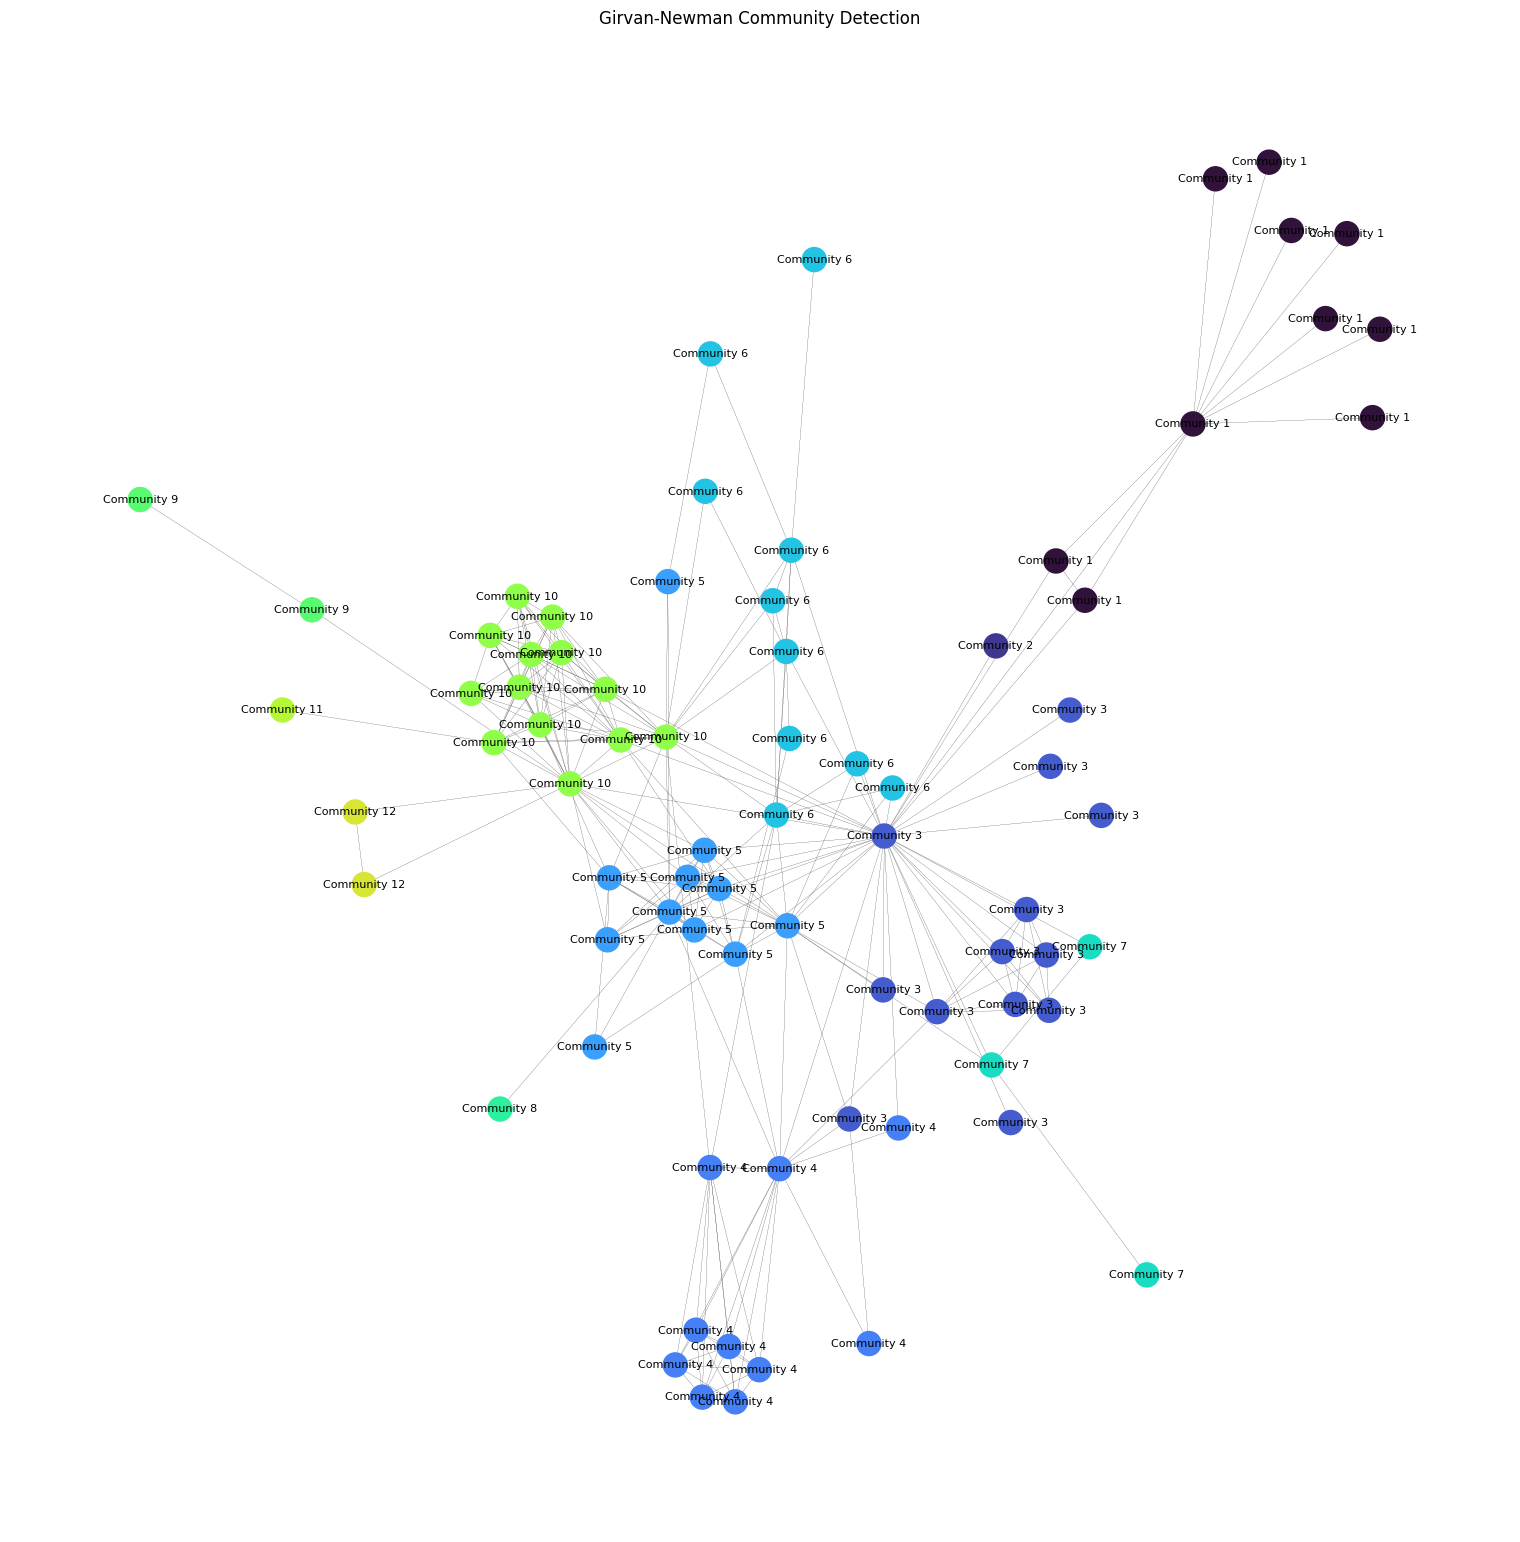

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman

def Girvan_newman_graph_communuties(G,k):
    # Apply Girvan-Newman algorithm
    communities_generator = girvan_newman(G)
    # Iterate over community partitions
    for level, communities in enumerate(communities_generator):
        # Convert communities to list format for easier handling
        node_groups = [list(community) for community in communities]
        # Optional: Stop after a certain number of levels
        if level == k: 
           break

    group_names = [f'Community {i+1}' for i in range(len(node_groups))]
    # Add the name attribute to each node in the communities
    for community, name in zip(node_groups, group_names):
        for node in community:
            G.nodes[node]['name'] = name 

    # Assign a color to each node based on its community
    node_colors = []
    colors = plt.cm.turbo(np.linspace(0, 1, k*2)) 
    for node in G:
        for i, community in enumerate(communities):
            if node in community:
                node_colors.append(colors[i])
                break

    pos = nx.spring_layout(G)
    fig = plt.figure(figsize = (15, 15)) 

    nx.draw(G, pos, node_color=node_colors, width=0.1, with_labels=False, node_size=200)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, label=f'Community {i+1}')
    nx.draw_networkx_edges(G, pos, width=0.1, edge_color='gray')
    labels = nx.get_node_attributes(G, 'name')
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
    plt.title('Girvan-Newman Community Detection')
    plt.axis("off")
    plt.show()

GD = nx.DiGraph(nx.read_gml(pathData))
GU = GD.to_undirected()
G = GU.copy()
Girvan_newman_graph_communuties(G,10)

# Link prediction
Link Prediction is a fundamental task in graph machine learning that aims to predict the likelihood of a connection between two nodes in a graph. We now focus on link prediction and tackle this problem using 2 methods: unsupervised and supervised.

## Unsupervised
We start by the unsupervised perspective. 
- We first build a Pandas Series from the edges of the graph and then select a sample of size 50 from this series.

We are assessing if the edges metrics' effectiveness in the sample have to be removed from a copied version of `g`.    
- Identify the comunuties in the graph using the appropriate community algorithm.   
- Identified edges communities to dertermine which edges might be candidate based on the communuties structure.   
- Select edges to remove, to separate the comumities while ensuring miminal impacts on the graph structure.   

**Girvan-Newman Algorithm**

To identify which edges to remove in order to enhance community structures in a network, we use the Girvan-Newman algorithm.   
This algorithm is specifically designed to detect communities by progressively removing edges that are most likely to connect different communities.  

- The Girvan-Newman algorithm identifies communities by removing edges with the highest betweenness centrality. 
- Betweenness centrality measures the number of shortest paths passing through an edge, 
- it makes a good indicator of edges that bridge different communities.  

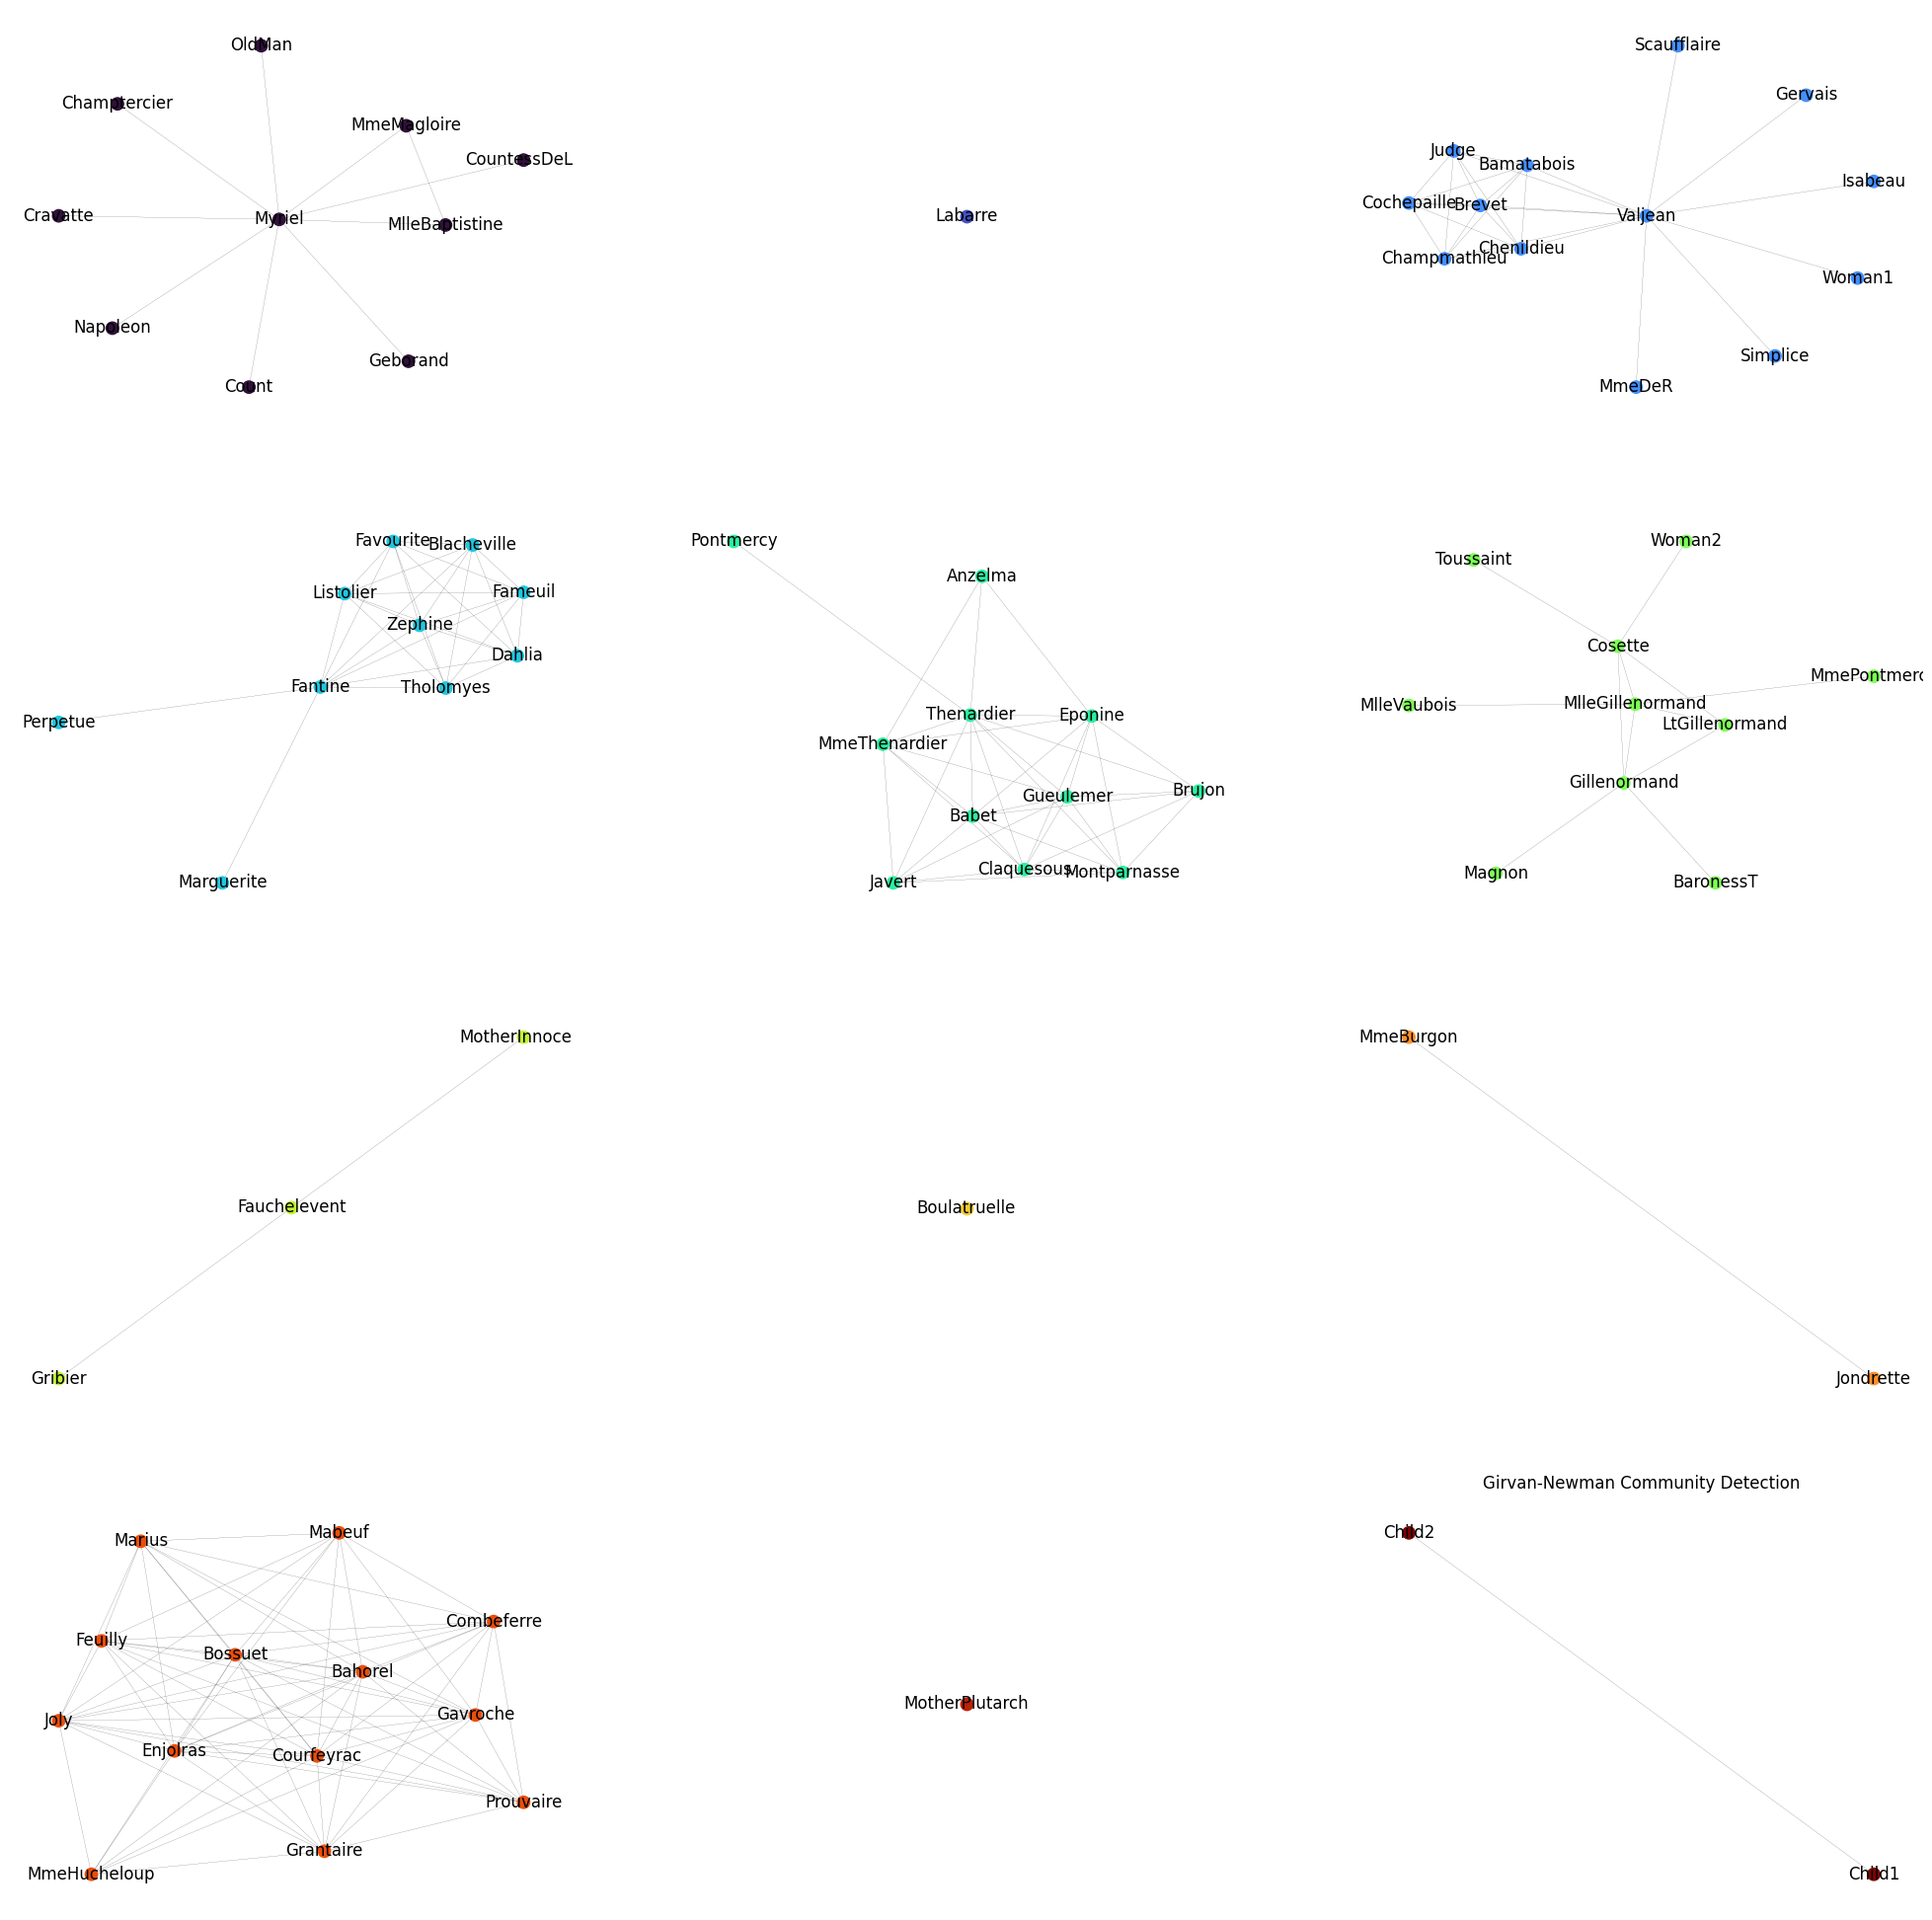

In [13]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman

def Girvan_newman_graph_communuties(G,k):
    
    communities_generator = girvan_newman(G)
    for level, communities in enumerate(communities_generator):
        node_groups = [list(community) for community in communities]
        if level == k: 
           break
    # Assign a color to each node based on its community
    fig, axes = plt.subplots(nrows=(k//3)+1, ncols=3, figsize=(25, 25))
    colors = plt.cm.turbo(np.linspace(0, 1, len(node_groups)))

    for i, community in enumerate(node_groups):
        num_communities = len(community)       
        subgraph = G.subgraph(community)
        ax = axes[i//3][i%3]       
        subgraph_colors = [colors[i] for node in subgraph]
        nx.draw(subgraph, ax=ax, node_color=subgraph_colors, width=0.1, with_labels=True, font_size=12, node_size=80)
        plt.title('Girvan-Newman Community Detection')   
    plt.show()           

GD = nx.DiGraph(nx.read_gml(pathData))
GU = GD.to_undirected()
G = GU.copy()
Girvan_newman_graph_communuties(G,10)

**Steps to Identify Edges for Removal**  
 - **Detect Communities**: 
   - Use a community detection algorithm to identify the communities within your graph. 
   - In this example, we use the Girvan newman method.
- **Analyze Edges**: 
  - Check each edge to see if it connects nodes from different communities. 
  - These edges are potential candidates for removal.
- **Remove Cross-Community Edges**: 
  - Removing edges that connect communities analyzing the modularity and cohesion of the network

Here's how it works and how you can implement it using NetworkX:

**Steps of the Algorithm**

 - *Calculate Edge Betweenness*: Compute the betweenness centrality for all edges in the graph.
 - *Remove Edge with Highest Betweenness*: Remove the edge with the highest betweenness centrality score.
 - *Recalculate Betweenness*: Recompute betweenness centrality for the remaining edges.
 - *Repeat*: Continue removing edges and recalculating until the desired community structure is achieved.

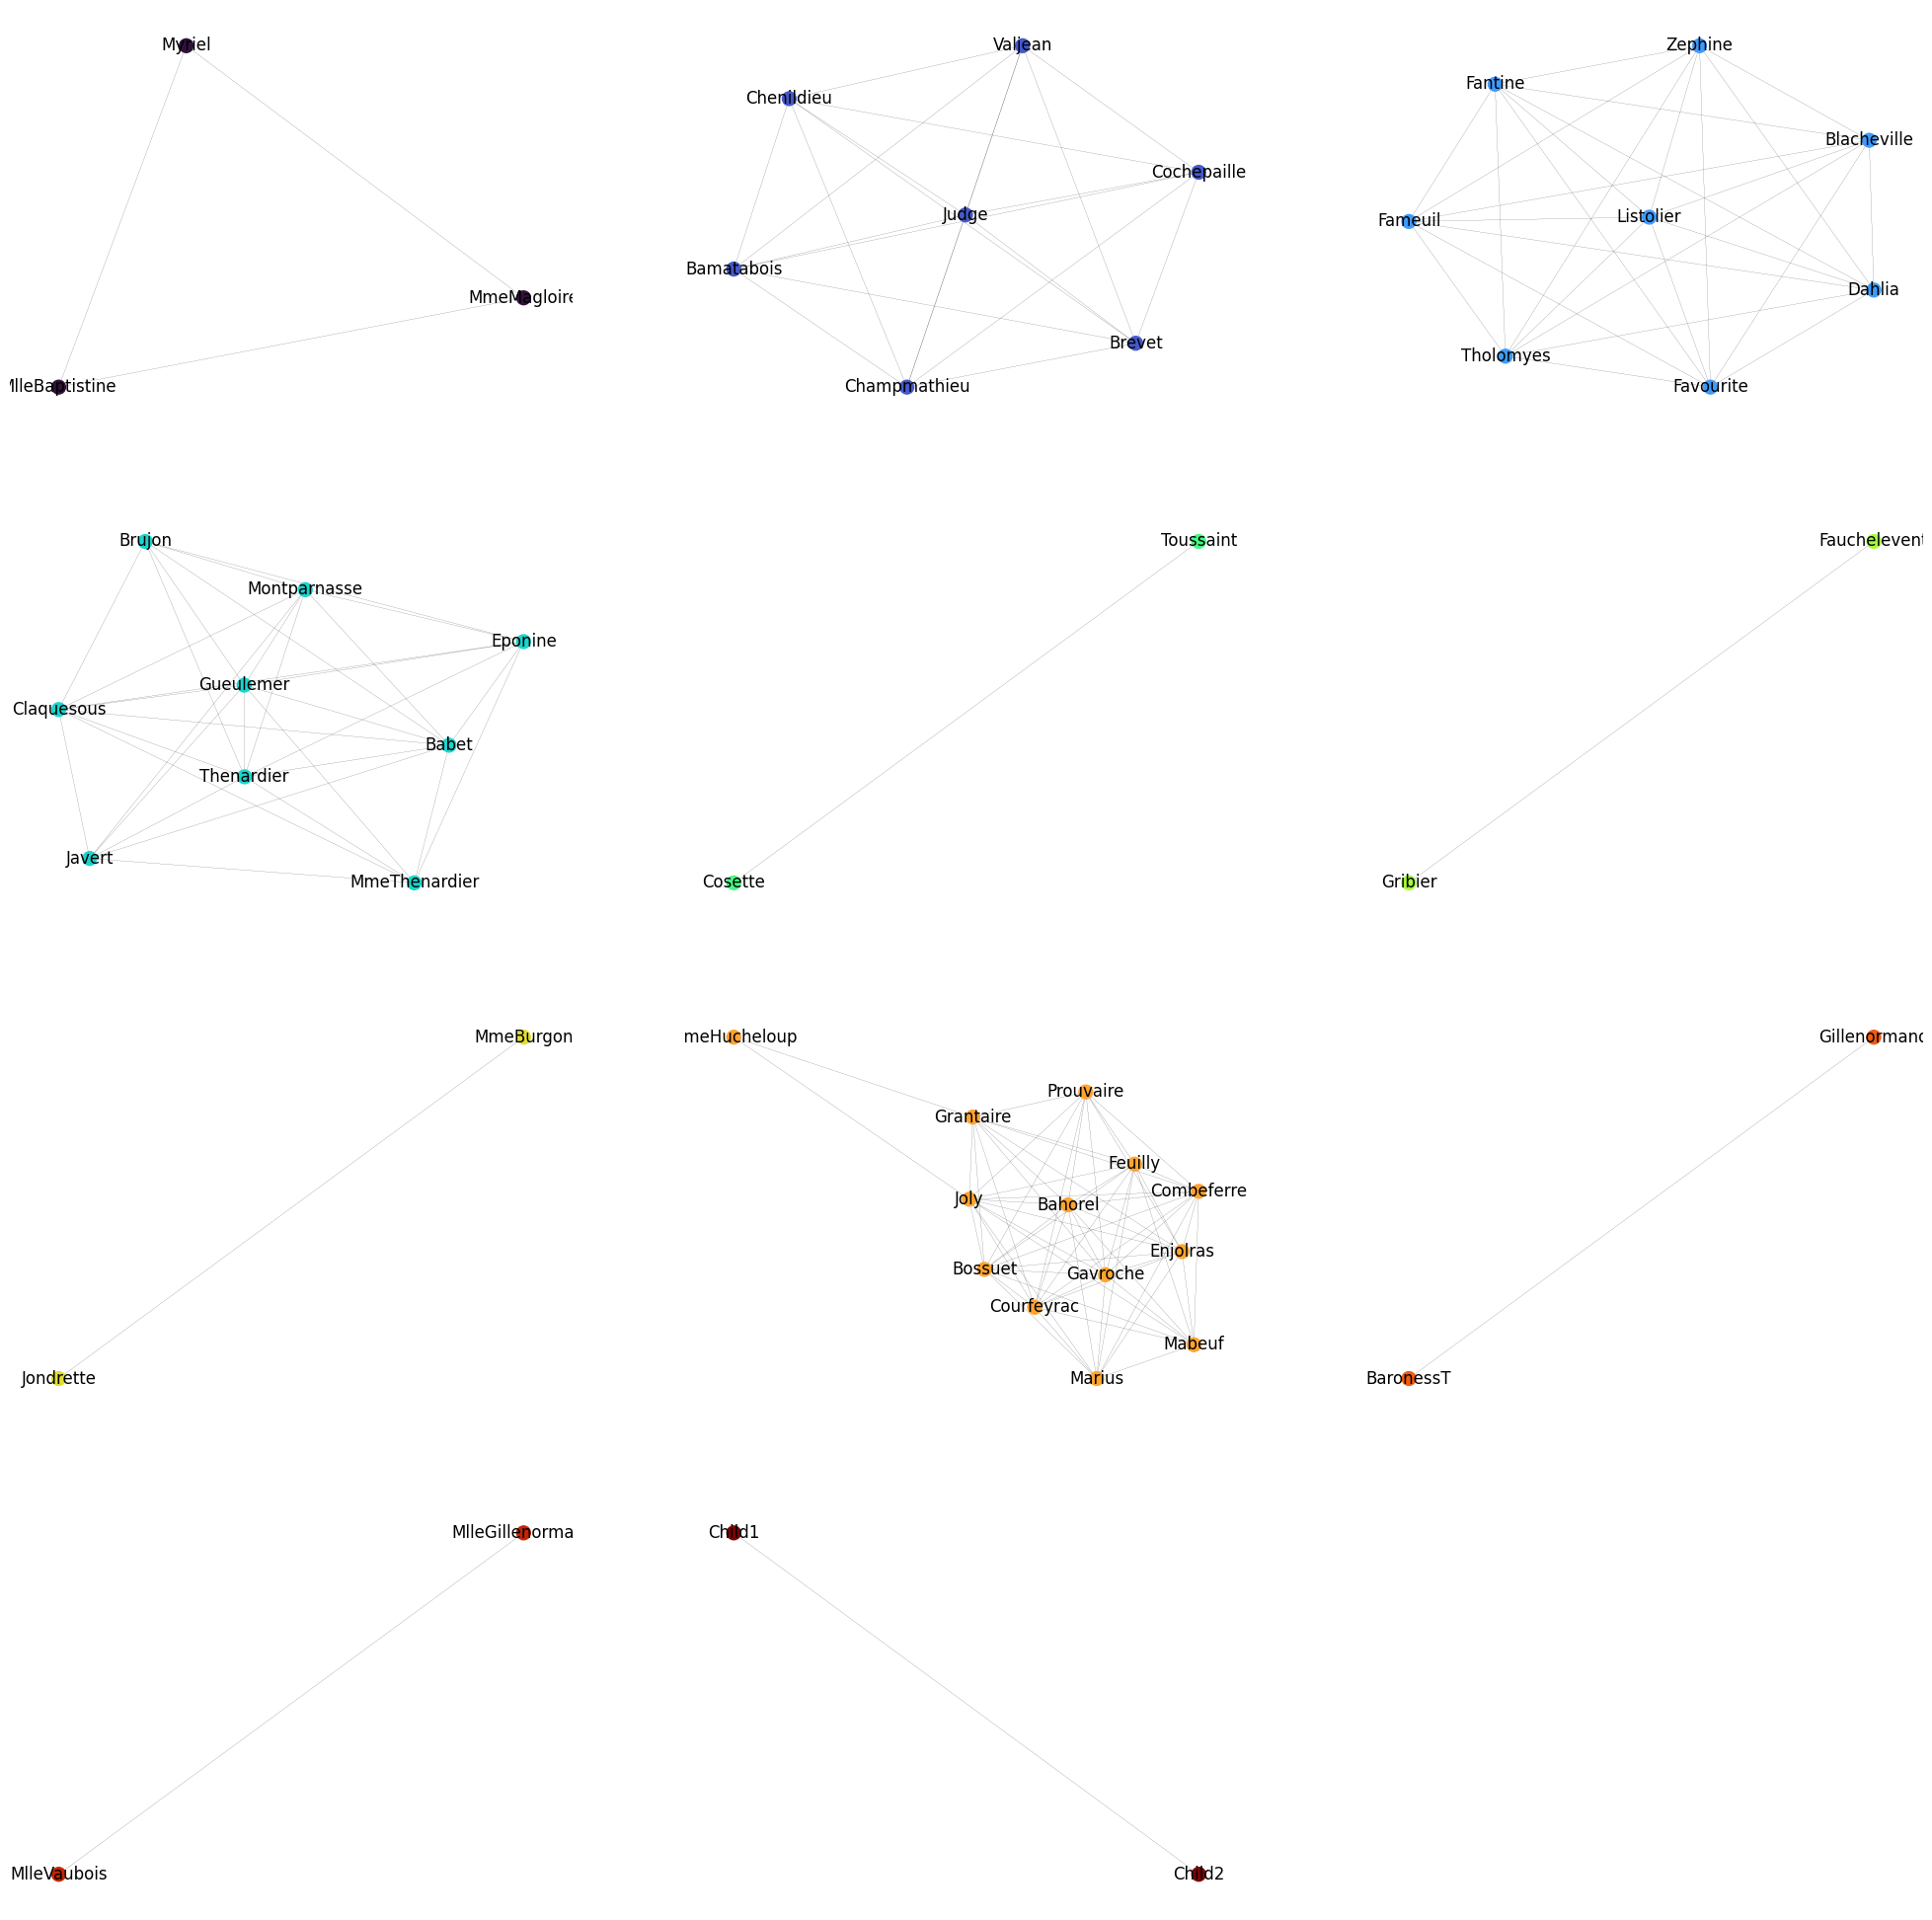

In [14]:
import operator

def split_graph(G): 
    for i in range(100):
        edge_betweenness = nx.edge_betweenness_centrality(G)
        if edge_betweenness == 0 :
            break
        highest_betweenness_edge = max(edge_betweenness.items(), key=operator.itemgetter(1))[0]
        G.remove_edge(*highest_betweenness_edge)
    return G    

def find_connected_components(grph):
    graph = split_graph(grph)
    visited = set()
    components = []

    def dfs(node, component):
        visited.add(node)
        component.append(node)
        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                dfs(neighbor, component)

    for node in graph.nodes():
        if node not in visited:
            component = []
            dfs(node, component)
            components.append(component)
    display_communities(components)

def display_communities(node_groups):
    groups = [group for group in node_groups if len(group) >= 2 ]
    fig, axes = plt.subplots(nrows=(len(groups)//3)+1, ncols=3, figsize=(25, 25))
    colors = plt.cm.turbo(np.linspace(0, 1, len(groups)))
    for i, community in enumerate(groups):
        num_communities = len(community)  
        subgraph = G.subgraph(community)
        ax = axes[i//3][i%3]       
        subgraph_colors = [colors[i] for node in subgraph]
        nx.draw(subgraph, ax=ax, node_color=subgraph_colors, width=0.1, with_labels=True, font_size=12, node_size=100)
    plt.axis('off')    
    plt.show()

# Copy the graph
GD = nx.DiGraph(nx.read_gml(pathData))
GU = GD.to_undirected()
G = GU.copy()

find_connected_components(G)

We can calculate some metrics to determine the strength of a potential link between two nodes. We will then select the top 50 potential links and compare them to the one we have just removed to assess how effective are these metrics over this dataset. You will apply the following methodology:

  1. Calculate the metrics for all non-existant pairs of nodes
  2. Build a dataframe to store these scores and extract the top 50 potential links
  3. Use the `is in` function over the sample of edges to count how many removed edges are in the top 50
  
Repeat this process with the following link prediction metrics :
1. **Resource allocation index**
  - The Resource Allocation Index is a metric used in link prediction to estimate the likelihood of a link existing between two nodes in a network. It is based on the concept of shared neighbors.

    - $\large \sum_{w \in \Gamma ( u ) \cap \Gamma ( v )} \Large \frac{1}{| \Gamma ( w )|}$  where:
        - $\Gamma(u)$ is the set of neighbors of node $u$ 
        - $\Gamma(v)$ is the set of neighbors of node $v$       
        - The sum is over all common neighbors $w$ of nodes  $u$ and $v$.
        - $∣\Gamma(w)∣$ is the degree of node $w$. 
​	
2. **Jaccard coefficient**
  - The more **Common neighbours** that two nodes $N_i$, $N_j$ share, the more similar they are : 
     - $ \large \sigma (i,j) =\Large |N_i \cap N_j|$
  - The likelihood or **Jaccard score** of a node that is a neighbour of either $x$ or $y$ to be a common neighbour:  
     - $ \large \sigma (i,j) =\Large \frac{|N_i \cap N_j|}{|N_i \cup N_j|}$

3. **Adamic-Adar index**
  - If two nodes share a neighbour and that neighbour is a rare neighbour, it should have a higher impact on their similarity.
    - $\Large \sigma (i,j)= \large \sum_{Z \in N(u) \cap N(v)} \Large \frac{1}{log |N(Z)|}$
      
      - $\large N(z)$ is the degree or the count of edges incident to node $z$. 

4. **Preferential attachment**
  - Preferential Attachment is a concept often used in network theory to describe a mechanism by which networks grow.   
  - It is based on the idea that nodes with higher degrees (i.e., more connections) are more likely to receive new links.     
           
  - This concept is instrumental in explaining the formation of scale-free networks, where a few nodes have many connections while most nodes have relatively few.   
  
  - Nodes of higher degree have a higher likeliness of getting connected to incoming nodes.
    -  $\large \sigma (i,j) =\Large |N_i| . |N_j|$ 

In [15]:
import networkx as nx
import pandas as pd
import math as math

# Copy the graph
GD = nx.DiGraph(nx.read_gml(pathData))
GU = GD.to_undirected()
G = GU.copy()

# Identify all pairs of nodes
all_nodes = list(G.nodes)
# Find all existing edges
existing_edges = set(G.edges)
# Identify non-existent pairs of nodes
non_existent_pairs = [(u, v) for i, u in enumerate(all_nodes) for v in all_nodes[i+1:] if (u, v) not in existing_edges]

# Calculate Resource Allocation Index for non-existent pairs
results = []
for u, v in non_existent_pairs:    
    neighbors_u = set(G.neighbors(u))
    neighbors_v = set(G.neighbors(v))
    # Common neighbors similarity
    common_neighbors = neighbors_u.intersection(neighbors_v)
    # Resource allocation index 
    resource_index = sum(1 / G.degree(w) for w in common_neighbors if G.degree(w) > 0)
    # Jaccard score
    union_neighbors =  neighbors_u.union(neighbors_v)
    resource_index1 = sum(1 / G.degree(w) for w in union_neighbors if G.degree(w) > 0)
    jaccard_score = resource_index / resource_index1
    # Academic / Adar  
    academic_adar = sum(1 / math.log(G.degree(w)) for w in common_neighbors if G.degree(w) > 0)
    # Preferential attachment
    if u != v and G.degree(u)> 0 and G.degree(v) > 0:
       preferential_score =  G.degree(u) * G.degree(v)
    results.append((u, v, resource_index,jaccard_score, academic_adar, preferential_score))

# Convert results to a DataFrame
df_link_prediction = pd.DataFrame(results, columns=['Node1', 'Node2', 'Res. Alloc. Index', 'Jaccard score', 'Academic /Adar', 'Preferential Score'])
# Extract top 50 potential links based on Resource Allocation Index
df_srtlink_predictions = df_link_prediction.sort_values(by='Res. Alloc. Index', ascending=False).head(50)

# Assuming we have a list of removed edges for comparison
removed_edges = [(0, 9), (0, 16), (1, 2)]  # Example removed edges
# Create a set of top 50 links for easy comparison
top_set = set(zip(df_srtlink_predictions['Node1'], df_srtlink_predictions['Node2']))

# Count how many removed edges are in the top 50 potential links
count_removed_edges = sum(1 for edge in removed_edges if edge in top_set or (edge[1], edge[0]) in top_set)

print("Number of removed edges in the top 50 potential links:", count_removed_edges)
df_srtlink_predictions.head(10)

Number of removed edges in the top 50 potential links: 0


,Node1,Node2,Res. Alloc. Index,Jaccard score,Academic /Adar,Preferential Score
2157,Eponine,Gavroche,0.736932,0.199504,3.344808,242
2373,Gavroche,Claquesous,0.669736,0.199838,3.199561,220
1484,MmeThenardier,Gillenormand,0.618687,0.249832,2.138783,77
777,Valjean,Eponine,0.617152,0.054403,2.875332,396
2513,Marius,Grantaire,0.614452,0.226603,3.111451,190
2512,Marius,Prouvaire,0.614452,0.240244,3.111451,171
2544,Mabeuf,Prouvaire,0.614452,0.330708,3.111451,99
2545,Mabeuf,Grantaire,0.614452,0.305400,3.111451,110
1598,Javert,Eponine,0.564520,0.168498,2.535709,187
2092,Pontmercy,MlleGillenormand,0.552632,0.259857,1.782318,21


In [16]:
import networkx as nx
import pandas as pd
import math as math

# Copy the graph
GD = nx.DiGraph(nx.read_gml(pathData))
GU = GD.to_undirected()
G = GU.copy()
 
pairs = [(u, v, G.degree(u) * G.degree(v)) for u in neighbors_u for v in neighbors_v if u != v and G.degree(u)> 0 and G.degree(v) > 0]
#preferencial_index = [G.degree(w) for w in neighbors_u if G.degree(w) > 0]

# Identify all pairs of nodes
all_nodes = list(G.nodes)
# Find all existing edges
existing_edges = set(G.edges)
# Identify non-existent pairs of nodes
non_existent_pairs = [(u, v) for i, u in enumerate(all_nodes) for v in all_nodes[i+1:] if (u, v) not in existing_edges]

# Access preferential attachment for each pair in non_existent_pairs
results = []
for u, v in non_existent_pairs:
    # Resource allocation index 
    rai = nx.resource_allocation_index(G, [(u, v)])
    u, v, score_rai  = next(rai)
    # Jaccard score
    jac = nx.jaccard_coefficient(G, [(u, v)])
    u, v, score_jac  = next(jac)
    # Academic / Adar 
    acad = nx.adamic_adar_index(G, [(u, v)])
    u, v, score_acad  = next(acad)
    # Preferential attachment
    prefAtt = nx.preferential_attachment(G, [(u, v)])
    u, v, score_prefAtt  = next(prefAtt)
    # Iterate over the generator and print results
    
    results.append((u, v, score_rai, score_jac, score_acad, score_prefAtt))

# Convert results to a DataFrame
df_link_prediction = pd.DataFrame(results, columns=['Node1', 'Node2', 'Res. Alloc. Index', 'Jaccard score', 'Academic /Adar', 'Preferential Score'])
# Extract top 50 potential links based on Resource Allocation Index
df_srtlink_predictions = df_link_prediction.sort_values(by='Res. Alloc. Index', ascending=False).head(50)

df_srtlink_predictions.head(10)

,Node1,Node2,Res. Alloc. Index,Jaccard score,Academic /Adar,Preferential Score
2157,Eponine,Gavroche,0.736932,0.320000,3.344808,242
2373,Gavroche,Claquesous,0.669736,0.333333,3.199561,220
1484,MmeThenardier,Gillenormand,0.618687,0.200000,2.138783,77
777,Valjean,Eponine,0.617152,0.175000,2.875332,396
2513,Marius,Grantaire,0.614452,0.380952,3.111451,190
2512,Marius,Prouvaire,0.614452,0.400000,3.111451,171
2544,Mabeuf,Prouvaire,0.614452,0.666667,3.111451,99
2545,Mabeuf,Grantaire,0.614452,0.615385,3.111451,110
1598,Javert,Eponine,0.564520,0.272727,2.535709,187
2092,Pontmercy,MlleGillenormand,0.552632,0.250000,1.782318,21


## Supervised
Here's an explanation of Link Prediction as a supervised learning task:

**Link Prediction Overview**     

Link Prediction involves training a model to learn where relationship should exist between pairs of nodes in a graph. 
It's typically framed as a binary classification problem, where the model predicts whether a link between two nodes exists or not.

**Feature Extraction** .  
The first step in Link Prediction is to extract relevant features for each node pair:
- **Topological Feature**: These are derived from the graph structure itself, such as:    
 
    - *Common neighbors*   
    - *Jaccard coefficient*      
    - *Adamic/Adar index*     
    - *Preferential attachment score*    
- **Node Attribute**: If available, node-specific attributes can be incorporated.    
- **Graph Neural Network Embedding**: Advanced techniques use GNNs to learn node representations that capture both structural and attribute information.

**Training Data Preparation**
To train a supervised Link Prediction model, we need to create a dataset of positive and negative examples:

 - *Positive Examples*: These are existing edges in the graph.
 - *Negative Examples*: These are sampled from non-adjacent node pairs.
 - *Feature Vector* : For each example, we create a feature vector by combining the features of the two nodes involved. 

**Model Training**
With the prepared dataset, we can train a binary classifier:
 - Algorithm Selection: Common choices include Logistic Regression, Random Forests, or Neural Networks.
 - Training Proces: The model learns to distinguish between positive and negative examples based on their feature vectors.
 - Cross-Validation: To ensure robustness, k-fold cross-validation is often employed.

**Model Evaluation**
The trained model's performance is typically evaluated using metrics such as:
 - *Area Under the ROC Curve (AUC-ROC)*
 - *Precision*
 - *Recall*
 - *F1-score*

**Prediction**
Once trained, the model can predict the likelihood of a link between any two nodes in the graph:

 - 1°) Extract features for the node pair.    
 - 2°) Apply the trained model to get a probability score.    
 - 3°) Use a threshold to classify the prediction as a link or non-link.   

**Advanced Techniques**
Recent advancements in Link Prediction include:

- *Graph Neural Network*: Graph Convolutional Networks and GraphSAGE can learn powerful node representations.
- *Subgraph-based Methods*: Extract local subgraphs around target links and apply graph-level GNNs to learn link representations.
 - *Temporal Link Prediction*: For dynamic graphs, methods like CTDNE incorporate temporal information.

By leveraging the graph structure, node attributes, and advanced machine learning techniques, Link Prediction provides valuable insights for various applications, including recommendation systems, knowledge graph completion, and social network analysis.

:::

 - From previous results, it is hard to say that the above-used features are outstanding... 
 - We now try to combine them in a supervised setting. To achieve this, please carrefully apply the following procedure.

:::

**1/ Set a variable `sizeTestSet` to 50**
 - a variable `sizeTrainingPositiveSet` to the number of edges in g minus the size of the test set and, 
 - a variable `sizeTrainingSet` to 2 times the size of the positive training set.

In [17]:
# Copy the graph
GD = nx.DiGraph(nx.read_gml(pathData))
GU = GD.to_undirected()
# copy the graph g into `g_training`.

In [18]:
sizeTestSet = 50
sizeTrainingPositiveSet = len(GU.edges()) - sizeTestSet
sizeTrainingSet = 2 * sizeTrainingPositiveSet
print(f'size TestSet                : {sizeTestSet} ')
print(f'size TrainingPositiveSet    : {sizeTrainingPositiveSet}')

size TestSet                : 50 
size TrainingPositiveSet    : 204


2/ **We will build the positive training set and the test set.**
 - To do so, 
   - first copy the graph `g` into `g_training`. 
   - Second, generate a sample of size `sizeTestSet`, denoted by `sampleTest`, from the series of edges of `g_training`. 
   
 - This sample will be your test set (we will apply our model on it and hope the existence of a link will be predicted). 
 - Then, remove from `g_training` the edges in `sampleTest`. 
 - Finally, convert the remaining edges as a series.

In [19]:
g_training = GU.copy()

In [20]:
# generate a sample of size sizeTestSet, denoted by sampleTest` from the series of edges of g_training. 
random_sampleTest = random.sample(list(g_training.nodes()), sizeTestSet)
# Get edges for the sampled nodes
sampletest = [(u, v) for u in random_sampleTest for v in random_sampleTest if g_training.has_edge(u, v)]
# Then, remove from g_training the edges in sampleTest
g_training.remove_edges_from(sampletest[:sizeTestSet])

**3/ To balance the training set,** 
 - we will randomly pick pairs of unconnected vertices (negative class). 
 - The number of pairs should be equal to the number of considered connections (positive class) in the training set. 
 - Find a way to generate this negative training set and name it `sampleNegativeTraining`.

  - **Positive / Negative Examples**
    - Positive examples are typically the existing edges in the graph.    
    - Negative examples are node pairs that do not have an edge between them in the existing graph.

In [21]:
# Identify all pairs of nodes
all_nodes = list(g_training.nodes)
existent_pairs = [(u, v) for i, u in enumerate(all_nodes) for v in all_nodes[i+1:] if (u, v) if g_training.has_edge(u,v)]
# Find all existing edges
existing_edges = g_training.edges
# Identify non-existent pairs of nodes
non_existent_pairs = [(u, v) for i, u in enumerate(all_nodes) for v in all_nodes[i+1:] if (u, v) not in existing_edges]
# Select a random subset of nodes
sampleNegativeTraining = random.sample(non_existent_pairs, sizeTrainingPositiveSet)
samplePositiveTraining = random.sample(existent_pairs, sizeTrainingPositiveSet)

4/ It is now time to calculate the features for each member of the training and test sets.    

The features list is presented below:
  1. size of the shortest path
  2. number of shortest paths
  3. for each community algorithm, does the vertices associated to a connection belongs to the same community (except -1) : 1 or 0
  4. for each link prediction algorithm, the strength of the connection
  
The feature list is:

In [22]:
features = [
    "lShortestPath",
    "nbShortestPath",
    "bipartition",
    "percolation",
    "fluid",
    "girvan",
    "resource",
    "jaccard",
    "adamic",
    "preferential",
    "class"
]

In [23]:

sampleNegativeTraining = pd.DataFrame(sampleNegativeTraining)
samplePositiveTraining = pd.DataFrame(samplePositiveTraining)

sampleTraining = pd.concat([samplePositiveTraining, sampleNegativeTraining],ignore_index=True)

In [24]:
print(f'size TestSet                : {sizeTestSet} ')
print(f'size TrainingPositiveSet    : {sizeTrainingPositiveSet}')
print(f'size all_nodes              : {len(all_nodes)}')
print(f'size non_existent_pairs     : {len(non_existent_pairs)}')
print(f'size samplePositiveTraining : {len(samplePositiveTraining)}')
print(f'size sampleNegativeTraining : {len(sampleNegativeTraining)}')
print(f'size sizeTrainingSet        : {sizeTrainingSet}')
print(f'size sampleTraining         : {sampleTraining.size}')

size TestSet                : 50 
size TrainingPositiveSet    : 204
size all_nodes              : 77
size non_existent_pairs     : 2718
size samplePositiveTraining : 204
size sampleNegativeTraining : 204
size sizeTrainingSet        : 408
size sampleTraining         : 816


**5/ Use the following code**
 - Use and modify it if necessary to create 2 empty data frames (one for the training set and the other for the test set).
 - We create dataframe for each dataset training and test with 11 colums of the features. 

In [25]:
dfTest = pd.DataFrame(
        np.zeros((sizeTestSet, 11)), 
        columns=features, 
        index= pd.MultiIndex.from_tuples(random_sampleTest))

dfTraining = pd.DataFrame(
        np.zeros((sizeTrainingSet, 11)), 
        columns=features, 
        index= pd.MultiIndex.from_tuples(list(zip(sampleTraining.iloc[:, 0], sampleTraining.iloc[:, 1]))))

**6/ Write a function** `calculateFeatures` **with the following specifications**:

INPUT : 
  - `sample`: the series of edges you want to calculate the feature values
  - `df`: the data frame you want to update
  - `training`: True if edges in `sample` are in the training set and False otherwise
  - `positive`: True if `training = True` and positive instances are considered
 
OUTPUT
  - No output

OBJECTIVE

Update `df` (the rows such that their indexes are in `sample`) with the feature values

In [26]:
from networkx.algorithms import community
import itertools

def calculateFeatures(G, df, training=False, positive=False):

    df = df.sort_index()
    for index, _ in df.iterrows():
        u, v = index      
        # Shortest Path features
        try:
            shortest_path = nx.shortest_path(G, u, v)
            df.loc[(u, v), 'lShortestPath'] = len(shortest_path) - 1
            df.loc[(u, v), 'nbShortestPath'] = sum(1 for _ in nx.all_shortest_paths(G, u, v))
        except nx.NetworkXNoPath:
            df.loc[(u, v), 'lShortestPath'] = -1
            df.loc[(u, v), 'nbShortestPath'] = 0        
        # Bipartition (assuming we have a bipartite graph)
        com_1, com_2 = kernighan_lin_bisection(G)  
        df.loc[(u, v), 'bipartition'] = 1 if (((u in com_1) and (v in com_1)) or ((u in com_2) and (v in com_2))) else 0       
        # Percolation (simplified version)
        df.loc[(u, v), 'percolation'] = nx.node_connectivity(G, u, v)       
        # Community detection features
        fluid_communities = list(community.asyn_fluidc(G, k=5))     
        df.loc[(u, v), 'fluid'] = 1 if any(u in c and v in c for c in fluid_communities) else 0
        # Community detection Girwan Newman
        girvan_newman = list(community.girvan_newman(G))   
        df.loc[(u, v), 'girvan'] = 1 if any(u in c and v in c for c in girvan_newman[7]) else 0    
        # Resource allocation index
        df.loc[(u, v), 'resource'] = list(nx.resource_allocation_index(G, [(u, v)]))[0][2]        
        # Jaccard coefficient
        df.loc[(u, v), 'jaccard'] = list(nx.jaccard_coefficient(G, [(u, v)]))[0][2]        
        # Adamic-Adar index
        df.loc[(u, v), 'adamic'] = list(nx.adamic_adar_index(G, [(u, v)]))[0][2]        
        # Preferential attachment
        df.loc[(u, v), 'preferential'] = list(nx.preferential_attachment(G, [(u, v)]))[0][2]        
        # Class (for training data)
        if training:
            df.loc[(u, v), 'class'] =  1 if positive else 0
    return df.copy()          


In [27]:
for index, _ in dfTraining.iterrows():
    u, v = index 
    girvan_newman = list(community.girvan_newman(G))   
    print(f'({u},{v}) { 1 if any(u in c and v in c for c in girvan_newman[7]) else 0}')    
    

(Javert,Simplice) 0
(Thenardier,Claquesous) 1
(Eponine,Marius) 1
(Javert,Woman1) 0
(Valjean,Toussaint) 0
(Tholomyes,Marius) 0
(Favourite,Zephine) 1
(Myriel,CountessDeLo) 1
(Gavroche,Grantaire) 1
(Enjolras,Joly) 1
(Myriel,Cravatte) 1
(Valjean,Brevet) 1
(Marius,Joly) 1
(Tholomyes,Favourite) 1
(Mabeuf,MotherPlutarch) 0
(Valjean,Enjolras) 0
(Gavroche,Courfeyrac) 1
(Marius,Bahorel) 1
(Gavroche,Mabeuf) 1
(Enjolras,Feuilly) 1
(Combeferre,Prouvaire) 1
(Fameuil,Zephine) 1
(Javert,Woman2) 0
(Brevet,Chenildieu) 1
(Tholomyes,Dahlia) 1
(Blacheville,Zephine) 1
(Mabeuf,Enjolras) 1
(Judge,Champmathieu) 1
(Mabeuf,Feuilly) 1
(Mabeuf,Bossuet) 1
(Mabeuf,Combeferre) 1
(Gavroche,Enjolras) 1
(MlleGillenormand,MlleVaubois) 1
(Valjean,Javert) 0
(MmeThenardier,Babet) 1
(MlleBaptistine,Valjean) 0
(Combeferre,Grantaire) 1
(Blacheville,Fantine) 1
(Perpetue,Simplice) 0
(Gillenormand,BaronessT) 1
(Bahorel,MmeHucheloup) 1
(Cosette,Woman2) 1
(Myriel,MmeMagloire) 1
(Combeferre,Courfeyrac) 1
(Javert,Gueulemer) 1
(Babet,

**7/ Call the function with the apropriate parameters (tips: it should be called 3 times)**

**Expected Classes:**
 - The "class" column is expected to contain binary values: 0 or 1.
    - 1 typically represents a positive class (e.g., an edge exists)
    - 0 typically represents a negative class (e.g., an edge doesn't exist)

**Our Specific Case:** .   
 - When we called calculateFeatures with training=True and positive=False. 
 - This means all edges in dfTraining should be assigned class 0.
 - So, when we print dfTraining["class"], we should expect to see a series of 0s, representing the negative class for all edges in our training set.   

**This binary classification is typically used in link prediction tasks:**
 - Class 1 (positive) would represent existing edges or edges that are likely to form.
 - Class 0 (negative) would represent non-existing edges or edges that are unlikely to form.

In our case, since we set positive=False, we're treating all edges in the training set as negative examples.     
This might not be what we want for a typical link prediction task, where we'd have a mix of positive and negative examples.

**For a more balanced approach:** . 
 
We might want to include both existing edges (positive class) and non-existing edges (negative class) in our training set.   
Assign class 1 to existing edges and class 0 to non-existing edges.    
This would give you a more representative dataset for training our DecisionTreeClassifier to predict whether an edge is likely to exist or not.

8/ Apply the following code and conclude:

In [122]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

GD = nx.DiGraph(nx.read_gml(pathData))
GU = GD.to_undirected()
G = GU.copy()

dfTraining = calculateFeatures(G, dfTraining, training=True, positive=True)
display(dfTraining)
features = list(dfTraining.columns[:10])
print(f'dfTraining["class"] : {dfTraining["class"]}')
y = dfTraining["class"]
# Encode labels if necessary
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X = dfTraining[features]
dt = DecisionTreeClassifier(min_samples_split=10, random_state=99)
dt.fit(X, y_encoded)
dt.predict(dfTest[features])

lShortestPath  nbShortestPath  bipartition  percolation  \
Anzelma Bahorel                 3.0             5.0          0.0          3.0   
        Claquesous              2.0             3.0          1.0          3.0   
        MmeHucheloup            3.0             2.0          0.0          3.0   
Babet   Brujon                  1.0             1.0          1.0          7.0   
        Montparnasse            1.0             1.0          1.0          9.0   
...                             ...             ...          ...          ...   
Zephine Claquesous              3.0             4.0          0.0          2.0   
        Gavroche                3.0             4.0          1.0          2.0   
        Mabeuf                  3.0             1.0          1.0          2.0   
        Marius                  2.0             1.0          1.0          2.0   
        Toussaint               3.0             3.0          0.0          2.0   

                      fluid  girvan  resource   jaccard    adamic  \
Anzelma Bahorel         0.0     1.0  0.000000  0.000000  0.000000   
        Claquesous      1.0     1.0  0.244318  0.300000  1.194739   
        MmeHucheloup    0.0     1.0  0.000000  0.000000  0.000000   
Babet   Brujon          1.0     1.0  0.509975  0.545455  2.424930   
        Montparnasse    1.0     1.0  0.628322  0.727273  3.115720   
...                     ...     ...       ...       ...       ...   
Zephine Claquesous      0.0     0.0  0.000000  0.000000  0.000000   
        Gavroche        0.0     0.0  0.000000  0.000000  0.000000   
        Mabeuf          0.0     0.0  0.000000  0.000000  0.000000   
        Marius          0.0     0.0  0.111111  0.040000  0.455120   
        Toussaint       0.0     0.0  0.000000  0.000000  0.000000   

                      preferential class  
Anzelma Bahorel               36.0     1  
        Claquesous            30.0     1  
        MmeHucheloup          21.0     1  
Babet   Brujon                70.0     1  
        Montparnasse          90.0     1  
...                            ...   ...  
Zephine Claquesous            70.0     1  
        Gavroche             154.0     1  
        Mabeuf                77.0     1  
        Marius               133.0     1  
        Toussaint             21.0     1  

[408 rows x 11 columns]

dfTraining["class"] : Anzelma  Bahorel         1
         Claquesous      1
         MmeHucheloup    1
Babet    Brujon          1
         Montparnasse    1
                        ..
Zephine  Claquesous      1
         Gavroche        1
         Mabeuf          1
         Marius          1
         Toussaint       1
Name: class, Length: 408, dtype: object


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])